# Task 4: Valuation Analysis, 1926–1957

This analysis applies the dividend-based valuation model to the 1926–1957 subperiod of the combined U.S. series constructed in Task 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

data = pd.read_csv("combined_1825_2025.csv")

## 1. Sample and valuation variables

The analysis uses 1926–1957. For each year,

$$
Q_t=\log(S_t+D_t)-\log(S_{t-1}),
$$

$$
G_t=\log(D_t)-\log(D_{t-1}),
$$

and

$$
X_t=Q_t-G_t.
$$

The cumulative process for this subperiod is

$$
C_t=\sum_{j\leq t}X_j.
$$

In [2]:
df = data[(data["Year"] >= 1925) & (data["Year"] <= 1957)][
    ["Year", "S", "D"]
].copy()

df["Q"] = np.log(df["S"] + df["D"]) - np.log(df["S"].shift(1))
df["G"] = np.log(df["D"]) - np.log(df["D"].shift(1))
df["X"] = df["Q"] - df["G"]

sample = df[(df["Year"] >= 1926) & (df["Year"] <= 1957)].dropna(subset=["X"]).copy()
sample["C"] = sample["X"].cumsum()
sample["C_lag"] = sample["C"].shift(1)
sample["t"] = sample["Year"] - 1926

print("Valuation sample:", int(sample["Year"].min()), "-", int(sample["Year"].max()))
print("Annual observations:", len(sample))

Valuation sample: 1926 - 1957
Annual observations: 32


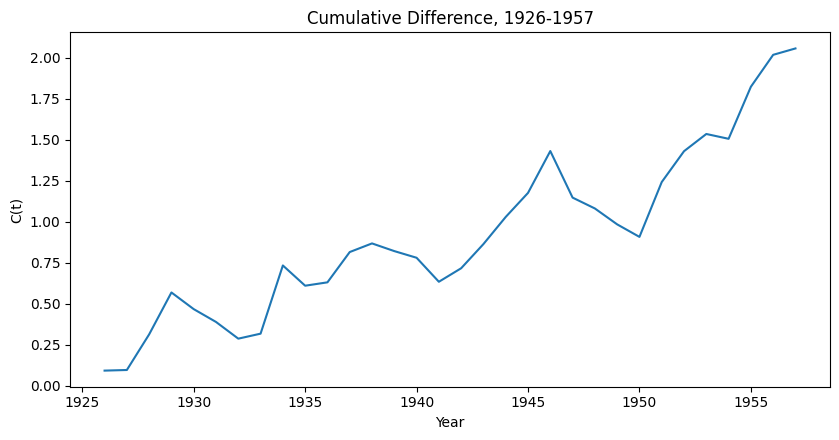

In [3]:
plt.figure(figsize=(8.5, 4.5))
plt.plot(sample["Year"], sample["C"])
plt.xlabel("Year")
plt.ylabel("C(t)")
plt.title("Cumulative Difference, 1926-1957")
plt.tight_layout()
plt.show()

## 2. Model estimation

The fitted equation is

$$
X_t=\alpha+\beta t-\gamma C_{t-1}+Z_t.
$$

The equivalent parameters are

$$
b=1-\gamma,\qquad
c=\frac{\beta}{\gamma},\qquad
a=\alpha-bc.
$$

In [4]:
reg = sample.dropna(subset=["C_lag"]).copy()

Xreg = sm.add_constant(reg[["t", "C_lag"]])
fit = sm.OLS(reg["X"], Xreg).fit()

alpha = fit.params["const"]
beta = fit.params["t"]
gamma = -fit.params["C_lag"]

b = 1 - gamma
c = beta / gamma
a = alpha - b*c

print("Regression sample:", int(reg["Year"].min()), "-", int(reg["Year"].max()))
print("Regression observations:", len(reg))
print()
print("a =", round(a, 6))
print("b =", round(b, 6))
print("c =", round(c, 6))
print("trend =", round(100*c, 2), "%")

Regression sample: 1927 - 1957
Regression observations: 31

a = 0.026521
b = 0.662911
c = 0.055113
trend = 5.51 %


## 3. Valuation measure and mean reversion

The detrended valuation measure is

$$
H_t=C_t-ct.
$$

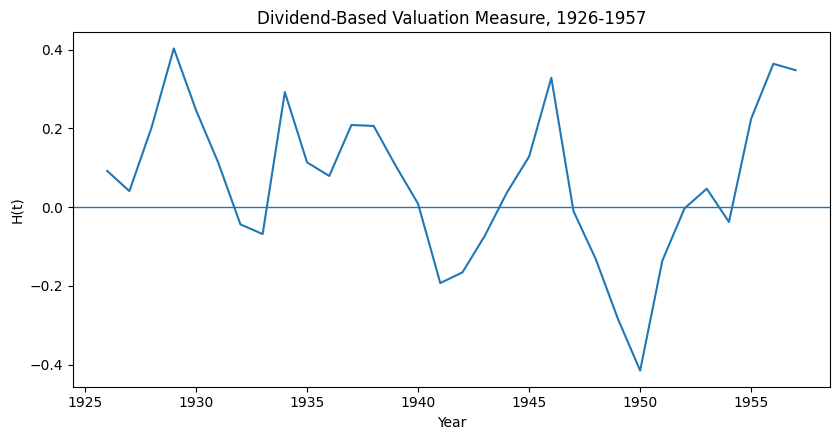

ADF statistic: -2.8651
ADF p-value: 0.0496
5% critical value: -2.9641


In [5]:
sample["H"] = sample["C"] - c*sample["t"]

plt.figure(figsize=(8.5, 4.5))
plt.plot(sample["Year"], sample["H"])
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("H(t)")
plt.title("Dividend-Based Valuation Measure, 1926-1957")
plt.tight_layout()
plt.show()

adf = adfuller(sample["H"].dropna(), regression="c", autolag="AIC")

print("ADF statistic:", round(adf[0], 4))
print("ADF p-value:", round(adf[1], 4))
print("5% critical value:", round(adf[4]["5%"], 4))

## 4. Confidence interval for the trend

Since $c=\beta/\gamma$, the interval uses the joint estimated covariance of $\widehat{\beta}$ and $\widehat{\gamma}$. The 95% interval is obtained from the simulated distribution of the ratio.

In [6]:
cov_fit = fit.cov_params()
cov_bg = np.array([
    [cov_fit.loc["t", "t"], -cov_fit.loc["t", "C_lag"]],
    [-cov_fit.loc["C_lag", "t"], cov_fit.loc["C_lag", "C_lag"]]
])

rng = np.random.default_rng(2026)
draws = rng.multivariate_normal([beta, gamma], cov_bg, size=100000)

# The ratio can be unstable in a short sample when gamma is close to zero.
valid = np.abs(draws[:, 1]) > 1e-8
c_sim = draws[valid, 0] / draws[valid, 1]
ci_low, ci_high = np.quantile(c_sim, [0.025, 0.975])

print("Estimated trend:", round(100*c, 2), "%")
print("95% ratio interval:", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")

Estimated trend: 5.51 %
95% ratio interval: (np.float64(2.72), np.float64(10.13)) %


## 5. Residual diagnostics

The residual ACF and Ljung-Box tests assess serial dependence in $Z_t$. Ljung-Box tests on $Z_t^2$ check for dependence in the residual variance. Gaussianity is examined with the Q-Q plot, Shapiro-Wilk test, and Jarque-Bera test.

The sample is short, so the diagnostic tests are interpreted with caution.

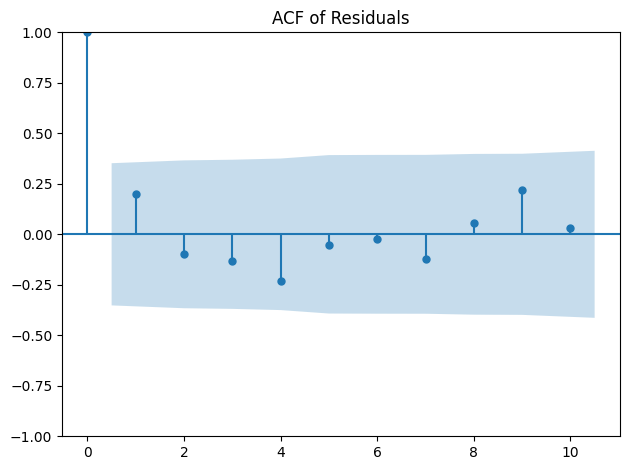

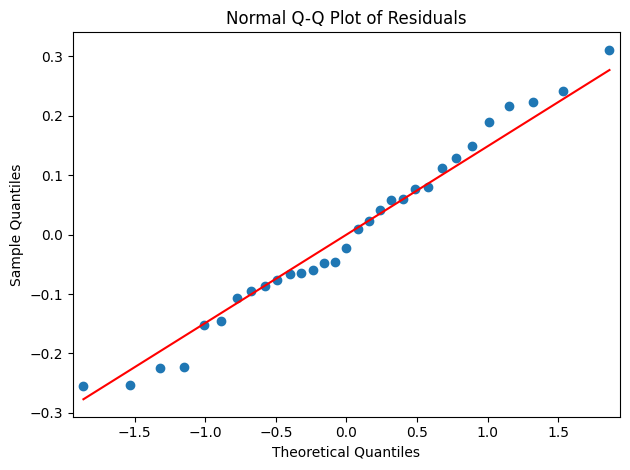

In [7]:
reg["Z"] = fit.resid

plot_acf(reg["Z"], lags=10)
plt.title("ACF of Residuals")
plt.tight_layout()
plt.show()

sm.qqplot(reg["Z"], line="s")
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

sw = shapiro(reg["Z"])
jb = jarque_bera(reg["Z"])
lb = acorr_ljungbox(reg["Z"], lags=[5, 10], return_df=True)
lb2 = acorr_ljungbox(reg["Z"]**2, lags=[5, 10], return_df=True)

In [8]:
print("Shapiro-Wilk p-value:", round(sw.pvalue, 4))
print("Jarque-Bera p-value:", round(jb.pvalue, 4))
print()
print("Ljung-Box for Z")
print(lb.round(4))
print()
print("Ljung-Box for Z^2")
print(lb2.round(4))

Shapiro-Wilk p-value: 0.6603
Jarque-Bera p-value: 0.6748

Ljung-Box for Z
    lb_stat  lb_pvalue
5    4.4815     0.4824
10   7.5511     0.6726

Ljung-Box for Z^2
    lb_stat  lb_pvalue
5    3.7543     0.5853
10   6.0451     0.8115


## 6. Comparison with the full historical sample

Task 3 estimates the same model over the much longer 1825–2025 history. The comparison below shows how the fitted parameters and diagnostics change when attention is restricted to 1926–1957.

In [9]:
comparison = pd.DataFrame({
    "Sample": ["1926-1957"],
    "b": [b],
    "c (%)": [100*c],
    "CI low (%)": [100*ci_low],
    "CI high (%)": [100*ci_high],
    "ADF p-value": [adf[1]],
    "Shapiro p-value": [sw.pvalue],
    "LB p-value (10)": [lb.loc[10, "lb_pvalue"]],
    "LB Z^2 p-value (10)": [lb2.loc[10, "lb_pvalue"]]
})

print(comparison.round(4).to_string(index=False))

   Sample      b  c (%)  CI low (%)  CI high (%)  ADF p-value  Shapiro p-value  LB p-value (10)  LB Z^2 p-value (10)
1926-1957 0.6629 5.5113       2.716      10.1337       0.0496           0.6603           0.6726               0.8115


## 7. Summary

In [10]:
print("Subperiod: 1926-1957")
print("Regression observations:", len(reg))
print("b =", round(b, 4))
print("c =", round(100*c, 2), "%")
print("95% ratio interval for c =", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")
print("ADF p-value =", round(adf[1], 4))
print("Shapiro-Wilk p-value =", round(sw.pvalue, 4))
print("Jarque-Bera p-value =", round(jb.pvalue, 4))
print("Ljung-Box p-value, lag 10 =", round(lb.loc[10, "lb_pvalue"], 4))
print("Ljung-Box Z^2 p-value, lag 10 =", round(lb2.loc[10, "lb_pvalue"], 4))

Subperiod: 1926-1957
Regression observations: 31
b = 0.6629
c = 5.51 %
95% ratio interval for c = (np.float64(2.72), np.float64(10.13)) %
ADF p-value = 0.0496
Shapiro-Wilk p-value = 0.6603
Jarque-Bera p-value = 0.6748
Ljung-Box p-value, lag 10 = 0.6726
Ljung-Box Z^2 p-value, lag 10 = 0.8115
